# Мульти-агентная система
Все чаще и чаще в работе используется ИИ для решения различных задач. Как правило, приходится перепроверять информацию, работая с несколькими моделями. Данная система предлагает вызов определенного количества моделей, зависящих от конкрентных задач, проверку ответов и суммаризацию результата.

## Цель проекта
Спроектировать и реализовать мульти-агентный pipeline, который по произвольному аналитически-прогнозному запросу пользователя автоматически подбирает команду из 2–10 LLM, запускает их параллельно через OpenRouter, фильтрует нерелевантные ответы и формирует консолидированный структурированный прогноз.
Система работает с открытыми LLM-провайдерами, доступными через OpenRouter.

## Задачи
1. Построить унифицированный транспорт к OpenRouter с retry, кэшированием и учетом стоимости использования.
2. Реализовать *Orchestrator*, который оценивает сложность запроса, формулирует идеальный промпт и подбирает состав агентов из актуального пула моделей.
3. Запустить выбранные модели параллельно и собрать ответы.
4. Оценить релевантность каждого ответа LLM-судьей, отфильтровать шум по установленному порогу.
5. Свернуть релевантные ответы в структурированный прогноз (консенсус / разногласия / прогноз / допущения / риски).
6. Обеспечить логирование и трассировку (JSONL), метрики (latency, стоимость, score) и визуализацию результатов.
7. Проверить поведение системы на практических кейсах: электромобили, ИИ в образовании, энергогенерация, рынок труда, биотехнологии долголетия, коммерческий космос, кибербезопасность, демографическое старение, водная безопасность, городская мобильность.

## Практическая значимость
- **Продуктовые команды:** оценка рисков и сценарный анализ перед запуском.
- **Журналистика данных / research:** reproducible pipeline с прозрачным расчетом вклада каждой модели.
- **Учебные/исследовательские задачи:** база для экспериментов с ensembling, debate, chain-of-thought и prompt-engineering.
- **Принятие бизнес-решений:** обоснование выбора одного из предложенных вариантов, подсвечивание потенциальных узких мест.

## Структура компонентов

| Слой | Класс | Роль |
|------|-------|------|
| Транспорт | `OpenRouterClient` | асинхронный клиент к OpenRouter API, retry, usage |
| Кэш | `ResponseCache` | файловый SHA-1 кэш `(model, prompt)` |
| Трассировка | `Tracer` | JSONL-лог всех событий pipeline |
| Координация | `Orchestrator` | анализ запроса, prompt engineering, подбор моделей |
| Исполнение | `WorkerAgent` / `WorkerPool` | параллельный вызов выбранных LLM |
| Контроль качества | `Evaluator` | оценка релевантности ответов |
| Агрегация | `Summarizer` | свёртка релевантных ответов в прогноз |
| Управление | `ForecastPipeline` | склейка всех этапов + UX |

## 0. Установка зависимостей

Импорт библиотек

In [4]:
from __future__ import annotations # для обработки аннотации типов

import os
import sys
import json
import time
import hashlib # модуль для хеширования
import asyncio # модуль для асинхронного программирования
import logging # модуль для логов
from pathlib import Path # “умный” путь к файлу
from dataclasses import dataclass, field, asdict # dataclasses - класс, где хранятся данные
from typing import List, Dict, Optional, Any, Callable, Awaitable

import aiohttp # библиотека для асинхронных HTTP-запросов
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type # tenacity - библиотека для повторных попыток


## 1. Логирование

Многие процессы при работе с готовыми моделями LLM скрыты от конеченого пользователя. Логирование позвоялет понять, что именно происходит не так, а также показывает, что вернул агент в качестве ответа.

В данной учебной работе часть логирования в коде будет являться избыточным, это сделано сознательно, чтобы максимально развернуто анализировать происходящие события в системе. При запуске в production это можно частично переработать.

In [5]:
_root = logging.getLogger("forecast")
_root.setLevel(logging.DEBUG)
_root.propagate = False
# чистим прошлые хендлеры, если ячейка перезапускается
for _h in list(_root.handlers):
    _root.removeHandler(_h)
_console = logging.StreamHandler(sys.stdout)
_console.setFormatter(logging.Formatter(
    "%(asctime)s | %(levelname)-7s | %(message)s", datefmt="%H:%M:%S",
))
_console.setLevel(logging.INFO)
_root.addHandler(_console)
log = _root

## 2. Диагностика API-ключа OpenRouter

Далее необхоидимо задать OPENROUTER API KEY, а также создать папки проекта для хранения файлов.

In [ ]:
OPENROUTER_BASE    = "https://openrouter.ai/api/v1"
try:
    OPENROUTER_API_KEY = "..."   # Необходимо вставить свой OPENROUTER API KEY
except NameError:
    OPENROUTER_API_KEY = ""


ART_DIR   = Path("artifacts");     ART_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path(".cache");        CACHE_DIR.mkdir(exist_ok=True)
TRACE_DIR = ART_DIR / "traces";    TRACE_DIR.mkdir(parents=True, exist_ok=True)

Код ниже делает минимальный прямой вызов OpenRouter для нескольких моделей разных провайдеров и выдает статус.

| Ошибка | Комментарий |
|---------|---------|
| Все модели → `OK` | Ключ живой; 403 возникает именно на контенте pipeline → править `ideal_prompt` |
| Все → `HTTP 403` | Блокировка на уровне ключа/аккаунта → чинить в кабинете OpenRouter |
| Часть → `OK`, часть → `403` | Провайдер-специфичное ограничение |
| Все → `HTTP 401` | Ключ невалидный / не тот скопирован |
| Все → `HTTP 402` | Нулевой баланс — пополнить `https://openrouter.ai/credits` |

In [7]:
async def check_models(models=None):
    """Пингует каждую модель и возвращает список доступных."""
    models = models or [
        "openai/gpt-4o-mini",
        "anthropic/claude-sonnet-4.5",
        "google/gemini-2.5-pro",
        "mistralai/mistral-large-2411",
        "meta-llama/llama-3.3-70b-instruct",
        "deepseek/deepseek-r1",
    ]
    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type":  "application/json",
    }

    async def _ping(mid):
        payload = {
            "model": mid,
            "messages": [{"role": "user", "content": "ping"}],
            "max_tokens": 4, "temperature": 0.0,
        }
        try:
            async with aiohttp.ClientSession(
                timeout=aiohttp.ClientTimeout(total=30)
            ) as s:
                async with s.post(f"{OPENROUTER_BASE}/chat/completions",
                                  headers=headers, data=json.dumps(payload)) as r:
                    return mid, r.status == 200
        except Exception:
            return mid, False

    results   = await asyncio.gather(*[_ping(m) for m in models])
    available = [mid for mid, ok in results if ok]

    for mid, ok in results:
        print(f"{'✓' if ok else '✗'} {mid}")
    print(f"\nДоступно: {len(available)}/{len(models)}")
    return available


# запуск
available_ids = await check_models()
print(f"\nМожно использовать: {available_ids}")

✗ openai/gpt-4o-mini
✗ anthropic/claude-sonnet-4.5
✗ google/gemini-2.5-pro
✓ mistralai/mistral-large-2411
✓ meta-llama/llama-3.3-70b-instruct
✓ deepseek/deepseek-r1

Доступно: 3/6

Можно использовать: ['mistralai/mistral-large-2411', 'meta-llama/llama-3.3-70b-instruct', 'deepseek/deepseek-r1']


Итак, модели от OpenAI / Anthropic / Google недоступны (провайдеры на OpenRouter блокируют их для нашего региона). Диагностика `check_models` показала, что у моего ключа доступны только open-source провайдеры.

In [8]:
AVAILABLE_MODELS: List[Dict[str, Any]] = [
    {"id": "mistralai/mistral-large-2411",       "strengths": ["balanced", "json-output", "european-context"],  "cost_per_1k": 0.002},
    {"id": "mistralai/mixtral-8x22b-instruct",   "strengths": ["moe", "code", "multilingual"],                  "cost_per_1k": 0.0012},
    {"id": "meta-llama/llama-3.3-70b-instruct",  "strengths": ["open", "fast", "longform"],                     "cost_per_1k": 0.0005},
    {"id": "deepseek/deepseek-r1",               "strengths": ["reasoning", "cheap", "deliberation"],           "cost_per_1k": 0.0008},
    {"id": "deepseek/deepseek-chat",             "strengths": ["general", "code", "fast"],                      "cost_per_1k": 0.00027},
    {"id": "qwen/qwen3-235b-a22b",               "strengths": ["moe", "multilingual", "reasoning"],             "cost_per_1k": 0.0013},
    {"id": "moonshotai/kimi-k2-0905",            "strengths": ["long-context", "agentic", "reasoning"],         "cost_per_1k": 0.0014},
    {"id": "deepseek/deepseek-v3.1-terminus",    "strengths": ["general", "reasoning", "fast"],                 "cost_per_1k": 0.0003},
    {"id": "nousresearch/hermes-4-70b",          "strengths": ["instruction-following", "structured-output", "reasoning"],  "cost_per_1k": 0.0005},
    {"id": "cohere/command-r-plus-08-2024",      "strengths": ["rag", "tool-use", "longform", "multilingual"],  "cost_per_1k": 0.0035},
]

ORCHESTRATOR_MODEL = "mistralai/mistral-large-2411"
EVALUATOR_MODEL    = "deepseek/deepseek-r1"
SUMMARIZER_MODEL   = "meta-llama/llama-3.3-70b-instruct"

RELEVANCE_THRESHOLD = 0.55   # минимальный порог релевантности
MAX_CONCURRENT      = 6      # ограничитель параллельных запросов
LOG_CONTENT_PREVIEW = 500    # ограничение по количеству символов в логе (при показе)


def _model_cost(model: str, total_tokens: int) -> float:
    """Рассчитывает стоимость запроса в USD.

    Использует поле cost_per_1k (цена за 1 000 токенов) из AVAILABLE_MODELS.
    Единая ставка распространяется на все токены (prompt + completion) — упрощение,
    достаточное для сравнительного учёта затрат внутри pipeline.
    Для моделей, не вошедших в каталог (ORCHESTRATOR / EVALUATOR / SUMMARIZER
    в роли специализированных вызовов), применяется консервативная оценка $0.002/1k.
    """
    for m in AVAILABLE_MODELS:
        if m["id"] == model:
            return round(m["cost_per_1k"] * total_tokens / 1000, 6)
    return round(0.002 * total_tokens / 1000, 6)

Расстановка ролей:

**ORCHESTRATOR_MODEL** = "mistralai/mistral-large-2411" — модель следует четкому плану.

**EVALUATOR_MODEL**    = "deepseek/deepseek-r1" — судья с сильными рассуждениями.

**SUMMARIZER_MODEL**   = "meta-llama/llama-3.3-70b-instruct" — модель способна создавать длинные связные тексты.

## 3. Кэш и трассировка

**ResponseCache** сохраняет ответы моделей на файловую систему по ключу. Это экономит деньги и ускоряет эксперименты — один и тот же запрос не тратит токены дважды.

**Tracer** осуществляет подробные записи того, что происходило во время работы системы.
На каждый запуск пишется:
- **`artifacts/traces/<run_id>.jsonl`** — машинно-читаемая трасса. Каждая строка — событие: `start`, `planned`, `plan_confirmed`, `llm_request`, `llm_response`, `cache_hit`, `llm_error`, `workers_done`, `eval_done`, `summary_done`. Полные тексты промптов и ответов сохраняются целиком.
- **`artifacts/traces/<run_id>.log`** — человекочитаемый журнал тех же событий с разделителями и полными промптами/ответами.

Оба файла сохраняются после каждой записи, так логи появляются в реальном времени во время работы скрипта.

In [9]:
class ResponseCache:
    def __init__(self, root: Path = CACHE_DIR):
        self.root = root
        self.root.mkdir(parents=True, exist_ok=True)

    def _key(self, model: str, messages: List[Dict[str, str]], params: Dict[str, Any]) -> str:
        payload = json.dumps(
            {"model": model, "messages": messages, "params": params},
            sort_keys=True, ensure_ascii=False,
        )
        return hashlib.sha1(payload.encode("utf-8")).hexdigest()

    def get(self, model: str, messages, params) -> Optional[Dict[str, Any]]:
        p = self.root / f"{self._key(model, messages, params)}.json"
        if p.exists():
            try:
                return json.loads(p.read_text(encoding="utf-8"))
            except Exception:
                return None
        return None

    def put(self, model, messages, params, value: Dict[str, Any]) -> None:
        p = self.root / f"{self._key(model, messages, params)}.json"
        p.write_text(json.dumps(value, ensure_ascii=False), encoding="utf-8")

In [10]:
def _preview(text: str, n: int = LOG_CONTENT_PREVIEW) -> str:
    """Безопасное превью длинной строки для вывода."""
    if text is None:
        return ""
    text = str(text)
    return text if len(text) <= n else text[:n] + f"… <+{len(text) - n} chars>"

In [11]:
class Tracer:
    """Двойной лог: JSONL (машинный) + .log (человеческий)."""

    def __init__(self, run_id: Optional[str] = None, root: Path = TRACE_DIR):
        root.mkdir(parents=True, exist_ok=True)
        self.run_id = run_id or time.strftime("run-%Y%m%d-%H%M%S")
        self.jsonl_path = root / f"{self.run_id}.jsonl"
        self.log_path   = root / f"{self.run_id}.log"
        self._jsonl = self.jsonl_path.open("a", encoding="utf-8", buffering=1)  # line-buffered
        self._log   = self.log_path.open("a",   encoding="utf-8", buffering=1)

        # К логгеру добавим обработчик, чтобы вызовы сохранялись также и в log-файл текущего запуска.
        self._fh = logging.FileHandler(self.log_path, encoding="utf-8")
        self._fh.setFormatter(logging.Formatter(
            "%(asctime)s | %(levelname)-7s | %(message)s", datefmt="%H:%M:%S",
        ))
        self._fh.setLevel(logging.DEBUG)
        log.addHandler(self._fh)

        self._write_log(f"=== RUN {self.run_id} STARTED @ {time.strftime('%Y-%m-%d %H:%M:%S')} ===")

    # Зафиксируем базовые внутренние технические методы, которые будут выполнять операцию записи в файл.
    def _write_jsonl(self, rec: Dict[str, Any]) -> None:
        self._jsonl.write(json.dumps(rec, ensure_ascii=False) + "\n")
        self._jsonl.flush()

    def _write_log(self, text: str) -> None:
        self._log.write(text + "\n")
        self._log.flush()

    # Публичный API для работы с объектом Tracer через понятные внешние методы, а не напрямую через внутренние служебные функции записи.
    def emit(self, event: str, **fields: Any) -> None:
        """Короткое структурное событие (без full-content)."""
        rec = {"ts": time.time(), "run_id": self.run_id, "event": event, **fields}
        self._write_jsonl(rec)
        self._write_log(f"\n[{time.strftime('%H:%M:%S')}] EVENT {event}")
        for k, v in fields.items():
            self._write_log(f"    {k}: {_preview(v, 2000)}")

    def log_user_query(self, query: str) -> None:
        self._write_jsonl({"ts": time.time(), "run_id": self.run_id,
                           "event": "user_query", "query": query})
        self._write_log("\n" + "=" * 72)
        self._write_log(f"USER QUERY\n{query}")
        self._write_log("=" * 72)
        log.info("USER QUERY: %s", _preview(query))

    def log_request(self, role: str, model: str, messages: List[Dict[str, str]],
                    params: Dict[str, Any]) -> None:
        """Фиксирует запрос к LLM со всеми сообщениями."""
        self._write_jsonl({
            "ts": time.time(), "run_id": self.run_id, "event": "llm_request",
            "role": role, "model": model, "messages": messages, "params": params,
        })
        self._write_log(f"\n--- REQUEST → {role} / {model} ---")
        for m in messages:
            self._write_log(f"[{m['role']}]\n{m['content']}")
        log.info("→ %s/%s  prompt=%d chars",
                 role, model, sum(len(m.get("content", "")) for m in messages))

    def log_response(self, role: str, model: str, content: str,
                     latency_s: float, cost_usd: float,
                     tokens: int, cached: bool, error: Optional[str]) -> None:
        """Фиксирует ответ LLM."""
        self._write_jsonl({
            "ts": time.time(), "run_id": self.run_id, "event": "llm_response",
            "role": role, "model": model, "content": content,
            "latency_s": latency_s, "cost_usd": cost_usd,
            "tokens": tokens, "cached": cached, "error": error,
        })
        self._write_log(f"\n--- RESPONSE ← {role} / {model} "
                        f"({latency_s:.2f}s, ${cost_usd:.4f}, "
                        f"{tokens} tok{', cached' if cached else ''}"
                        f"{', ERROR: ' + error if error else ''}) ---")
        self._write_log(content or "<empty>")
        if error:
            log.warning("← %s/%s  ERROR: %s", role, model, error)
        else:
            log.info("← %s/%s  %d chars | %.2fs | $%.4f%s",
                     role, model, len(content or ""), latency_s, cost_usd,
                     "  [CACHED]" if cached else "")
            log.debug("   preview: %s", _preview(content))

    def close(self) -> None:
        self._write_log(f"\n RUN {self.run_id} CLOSED @ {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
        try:
            log.removeHandler(self._fh)
            self._fh.close()
        except Exception:
            pass
        self._jsonl.close()
        self._log.close()

## 4. Настройка`OpenRouterClient`

Представляет собой асинхронный клиент для OpenRouter. Его задача — отправлять запросы к языковой модели и получать ответы в удобном для программы виде.

В клиенте реализованы следующие возможности:
*   единый интерфейс вызова модели через метод chat(model, messages, **params);
*   автоматические повторные попытки отправки запроса при временных сбоях сети или серверных ошибках;
*   подсчет служебной информации об использовании модели: числа токенов и примерной стоимости запроса;
*   поддержка кэширования ответов и трассировки работы системы;
*   ограничение количества одновременно выполняемых запросов, чтобы избежать слишком высокой нагрузки и ошибок, связанных с превышением лимита запросов.

In [12]:
class OpenRouterError(Exception):
    """Серверная ошибка OpenRouter (HTTP 5xx, 408, 429) — подлежит повторной попытке через tenacity."""


@dataclass
class LLMResponse:
    """Унифицированный контейнер ответа модели.

    Хранит не только текст ответа, но и всю служебную информацию:
    латентность, стоимость, количество токенов, флаг кэша и текст ошибки.
    Позволяет единообразно обрабатывать ответы во всех компонентах pipeline.
    """
    model: str
    content: str
    usage: Dict[str, Any] = field(default_factory=dict)
    latency_s: float = 0.0
    cost_usd: float = 0.0
    cached: bool = False
    error: Optional[str] = None

In [13]:
class OpenRouterClient:
    def __init__(
        self,
        api_key: str,
        base_url: str = OPENROUTER_BASE,
        timeout: int = 120,
        cache: Optional[ResponseCache] = None,
        tracer: Optional[Tracer] = None,
        max_concurrent: int = MAX_CONCURRENT,
    ):
        if not api_key:
            raise ValueError("OPENROUTER_API_KEY не установлен")
        self.api_key = api_key
        self.base_url = base_url.rstrip("/")
        self.timeout = aiohttp.ClientTimeout(total=timeout)
        self.cache = cache
        self.tracer = tracer
        self._sem = asyncio.Semaphore(max_concurrent)

    def _headers(self) -> Dict[str, str]:
        return {
            "Authorization": f"Bearer {self.api_key}",
            "Content-Type":  "application/json",
            "HTTP-Referer":  "https://local.notebook",
            "X-Title":       "Forecast Multi-Agent",
        }

    @retry(
        reraise=True,
        stop=stop_after_attempt(3),
        wait=wait_exponential(multiplier=1, min=1, max=10),
        retry=retry_if_exception_type((aiohttp.ClientError, asyncio.TimeoutError, OpenRouterError)),
    )
    async def _post(self, payload: Dict[str, Any]) -> Dict[str, Any]:
        async with self._sem:
            async with aiohttp.ClientSession(timeout=self.timeout) as s:
                async with s.post(
                    f"{self.base_url}/chat/completions",
                    headers=self._headers(),
                    data=json.dumps(payload),
                ) as resp:
                    data = await resp.json()
                    if resp.status >= 500 or resp.status in (408, 429):
                        raise OpenRouterError(f"HTTP {resp.status}: {data}")
                    if resp.status >= 400:
                        # 4xx — не ретраим
                        return {"_error": f"HTTP {resp.status}: {data}"}
                    return data

    async def chat(
        self,
        model: str,
        messages: List[Dict[str, str]],
        *,
        role: str = "llm",
        temperature: float = 0.4,
        max_tokens: int = 2048,
        response_format: Optional[Dict[str, Any]] = None,
        **kwargs,
    ) -> LLMResponse:
        """
        role: метка компонента — 'orchestrator' | 'worker:<model>' | 'evaluator' | 'summarizer'.
              Используется только для логирования — для аудита, какой именно компонент вызвал модель.
        """
        params = {"temperature": temperature, "max_tokens": max_tokens, **kwargs}
        if response_format is not None:
            params["response_format"] = response_format

        # 1) логируем запрос до вызова — чтобы при обрыве было видно, что просили
        if self.tracer:
            self.tracer.log_request(role, model, messages, params)

        # 2) кэш
        if self.cache:
            hit = self.cache.get(model, messages, params)
            if hit:
                if self.tracer:
                    self.tracer.log_response(
                        role=role, model=model, content=hit["content"],
                        latency_s=0.0, cost_usd=hit.get("cost_usd", 0.0),
                        tokens=int(hit.get("usage", {}).get("total_tokens", 0)),
                        cached=True, error=None,
                    )
                return LLMResponse(
                    model=model, content=hit["content"],
                    usage=hit.get("usage", {}), cost_usd=hit.get("cost_usd", 0.0),
                    cached=True,
                )

        payload = {"model": model, "messages": messages, **params}
        t0 = time.perf_counter()
        try:
            data = await self._post(payload)
        except Exception as e:           # noqa: BLE001
            latency = time.perf_counter() - t0
            if self.tracer:
                self.tracer.log_response(role=role, model=model, content="",
                                         latency_s=latency, cost_usd=0.0,
                                         tokens=0, cached=False, error=str(e))
            return LLMResponse(model=model, content="", error=str(e), latency_s=latency)

        latency = time.perf_counter() - t0
        if "_error" in data:
            if self.tracer:
                self.tracer.log_response(role=role, model=model, content="",
                                         latency_s=latency, cost_usd=0.0,
                                         tokens=0, cached=False, error=data["_error"])
            return LLMResponse(model=model, content="", error=data["_error"],
                               latency_s=latency)

        content = data["choices"][0]["message"]["content"]
        usage = data.get("usage", {})
        total_tokens = int(usage.get("total_tokens", 0))
        cost = _model_cost(model, total_tokens)
        result = LLMResponse(
            model=model, content=content, usage=usage,
            latency_s=latency, cost_usd=cost,
        )
        if self.cache:
            self.cache.put(model, messages, params, {
                "content": content, "usage": usage, "cost_usd": cost,
            })
        if self.tracer:
            self.tracer.log_response(role=role, model=model, content=content,
                                     latency_s=latency, cost_usd=cost,
                                     tokens=total_tokens, cached=False, error=None)
        return result

    async def chat_json(self, model, messages, *, role: str = "llm", **kw) -> Dict[str, Any]:
        resp = await self.chat(
            model=model, messages=messages, role=role,
            response_format={"type": "json_object"}, **kw,
        )
        if resp.error:
            raise RuntimeError(
                f"OpenRouter error in role={role!r} model={model!r}: {resp.error}"
            )
        content = (resp.content or "").strip()
        if not content:
            raise RuntimeError(
                f"Empty response from role={role!r} model={model!r}"
            )
        # снять markdown-обёртку ```json ... ``` если есть
        if content.startswith("```"):
            content = content.strip("`")
            if content.lower().startswith("json"):
                content = content[4:].lstrip()
            if content.endswith("```"):
                content = content[:-3].rstrip()
        try:
            return json.loads(content)
        except json.JSONDecodeError:
            s, e = content.find("{"), content.rfind("}")
            if s < 0 or e < 0:
                raise RuntimeError(
                    f"Non-JSON response from role={role!r} model={model!r}: "
                    f"{content[:200]!r}"
                )
            return json.loads(content[s:e + 1])

## 5. Orchestrator — базовый агент

Задачи:
1. **Оценить сложность** запроса (1–10).
2. **Сформулировать идеальный промпт** — self-contained, с требованием указывать уверенность, ключевые допущения и явным запретом на галлюцинации.
3. **Подобрать состав команды:** число агентов `N ∈ [2,10]` пропорционально сложности; выбираются разные провайдеры (декорреляция ошибок).

**LLMResponse** (определён в разделе 4 вместе с `OpenRouterClient`) — унифицированный контейнер ответа модели: хранит текст, латентность, стоимость, счётчик токенов, флаг кэша и сообщение об ошибке. Используется всеми компонентами pipeline как стандартный тип возвращаемого значения.

In [14]:
@dataclass
class OrchestratorPlan:
    user_query: str
    complexity: int
    rationale: str
    ideal_prompt: str
    models: List[str]
    expected_output_schema: str

    def pretty(self) -> str:
        return (
            f"Сложность: {self.complexity}/10\n"
            f"Агентов:   {len(self.models)}\n"
            f"Модели:    {', '.join(self.models)}\n"
            f"Обоснование: {self.rationale}\n\n"
            f"— ИДЕАЛЬНЫЙ ПРОМПТ —\n{self.ideal_prompt}"
        )


ORCHESTRATOR_SYSTEM = """Ты — главный координатор мульти-агентной системы прогнозирования.
По запросу пользователя спроектируй работу команды LLM-агентов.

Верни строго JSON:
{
  "complexity": <int 1..10>,
  "rationale": <string, 2-4 предложения>,
  "ideal_prompt": <string: самодостаточный промпт для worker-агента>,
  "num_agents": <int 2..10>,
  "model_ids": [<string>, ...],    // длина == num_agents, только из AVAILABLE
  "expected_output_schema": <string>
}

Правила:
- Число агентов пропорционально сложности: 1-3 → 1-2, 4-6 → 3-5, 7-8 → 6-8, 9-10 → 9-10.
- Выбирай модели разных провайдеров из списка AVAILABLE_MODELS.
- Дубликаты моделей запрещены.
- В ideal_prompt обязательно должно быть: контекст, требуемые источники/аргументация,
  структура ответа, требование указывать confidence (0..1) и допущения, запрет на галлюцинации (не выдумывай факты, источники, цитаты, числа или детали, которых нет во входных данных).
"""


class Orchestrator:
    def __init__(self, client: OpenRouterClient, model: str = ORCHESTRATOR_MODEL):
        self.client = client
        self.model = model

    async def plan(self, user_query: str) -> OrchestratorPlan:
        catalogue = "\n".join(
            f"- {m['id']} :: {', '.join(m['strengths'])}" for m in AVAILABLE_MODELS
        )
        user_msg = (
            f"AVAILABLE MODELS:\n{catalogue}\n\n"
            f"USER QUERY:\n{user_query}\n\n"
            "Сформируй план работы команды."
        )
        data = await self.client.chat_json(
            model=self.model,
            messages=[
                {"role": "system", "content": ORCHESTRATOR_SYSTEM},
                {"role": "user",   "content": user_msg},
            ],
            role="orchestrator",              # ← метка для лога
            temperature=0.3, max_tokens=1500,
        )
        num = max(2, min(10, int(data["num_agents"])))
        valid = {m["id"] for m in AVAILABLE_MODELS}
        models = [m for m in data["model_ids"] if m in valid][:num]
        # fallback: если модель посчитала невалидные id — добираем первыми из пула
        for m in AVAILABLE_MODELS:
            if len(models) >= num:
                break
            if m["id"] not in models:
                models.append(m["id"])
        return OrchestratorPlan(
            user_query=user_query,
            complexity=int(data["complexity"]),
            rationale=data["rationale"],
            ideal_prompt=data["ideal_prompt"],
            models=models,
            expected_output_schema=data["expected_output_schema"],
        )

## 6. Worker-агенты

Все worker-агенты работают с одним и тем же подготовленным промптом и запускаются одновременно через asyncio.gather. Это позволяет сократить общее время выполнения: мы ждем не каждый ответ по очереди, а только самый долгий из них. Кроме того, если у одного агента возникает ошибка, остальные все равно продолжают работать независимо.

In [15]:
@dataclass
class WorkerAnswer:
    model: str
    content: str
    usage: Dict[str, Any] = field(default_factory=dict)
    latency_s: float = 0.0
    cost_usd: float = 0.0
    cached: bool = False
    error: Optional[str] = None


class WorkerAgent:
    def __init__(self, client: OpenRouterClient, model: str):
        self.client = client
        self.model  = model

    async def run(self, ideal_prompt: str, user_query: str) -> WorkerAnswer:
        resp = await self.client.chat(
            model=self.model,
            messages=[
                {"role": "system", "content": ideal_prompt},
                {"role": "user",   "content": user_query},
            ],
            role=f"worker:{self.model}",       # ← метка для лога
            temperature=0.6, max_tokens=1800,
        )
        return WorkerAnswer(
            model=resp.model, content=resp.content, usage=resp.usage,
            latency_s=resp.latency_s, cost_usd=resp.cost_usd,
            cached=resp.cached, error=resp.error,
        )


class WorkerPool:
    def __init__(self, client: OpenRouterClient):
        self.client = client

    async def run(self, plan: OrchestratorPlan) -> List[WorkerAnswer]:
        tasks = [WorkerAgent(self.client, m).run(plan.ideal_prompt, plan.user_query)
                 for m in plan.models]
        return list(await asyncio.gather(*tasks))

## 7. Evaluator — оценка релевантности

Единый LLM-судья оценивает каждый ответ по критериям:
* (1) соответствие запросу,
* (2) наличие обоснований/данных,
* (3) отсутствие галлюцинаций,
* (4) наличие прогнозной части.

Шкала оценки 0...1 показывает степень релевантности ответа:
* 0.0 — ответ полностью нерелевантен (нет соответствия критериям).
* 1.0 — ответ идеально соответствует запросу по всем 4 критериям.
* Любое промежуточное значение (0.3, 0.55, 0.8, …) — частично релевантно.

Ответы ниже порога релевантности (RELEVANCE_THRESHOLD = 0.55) отбрасываются.

In [16]:
@dataclass
class Evaluation:
    model: str
    score: float
    verdict: str
    is_relevant: bool
    answer: str
    latency_s: float = 0.0
    cost_usd: float = 0.0


EVALUATOR_SYSTEM = """Ты — строгий рецензент. Оцени релевантность ответа исходному запросу
по шкале 0..1 и дай короткий вердикт.
Критерии:
 1. Отвечает ли именно на поставленный вопрос?
 2. Есть ли обоснование и данные?
 3. Нет ли явных галлюцинаций или противоречий?
 4. Есть ли прогнозная часть (числа, интервалы, сценарии)?
Верни JSON: { "score": <0..1>, "verdict": <string до 200 символов> }.
"""


class Evaluator:
    def __init__(self, client: OpenRouterClient, model: str = EVALUATOR_MODEL,
                 threshold: float = RELEVANCE_THRESHOLD):
        self.client = client
        self.model  = model
        self.threshold = threshold

    async def _score_one(self, user_query: str, ans: WorkerAnswer) -> Evaluation:
        # Если воркер сам упал — не тратим токены судьи.
        if ans.error or not (ans.content or "").strip():
            return Evaluation(ans.model, 0.0, f"error: {ans.error or 'empty'}",
                              False, ans.content)
        t0 = time.perf_counter()
        try:
            data = await self.client.chat_json(
                model=self.model,
                messages=[
                    {"role": "system", "content": EVALUATOR_SYSTEM},
                    {"role": "user",
                     "content": f"USER QUERY:\n{user_query}\n\nANSWER BY {ans.model}:\n{ans.content}"},
                ],
                role=f"evaluator:{ans.model}",     # метка для лога (кого судим)
                temperature=0.0, max_tokens=600,
            )
        except Exception as e:
            # Если судья сам упал — не роняем весь pipeline (помечаем ответ как неоцененный и идем дальше).
            log.warning("Evaluator failed for %s: %s", ans.model, e)
            return Evaluation(
                model=ans.model, score=0.0,
                verdict=f"judge failed: {str(e)[:160]}",
                is_relevant=False, answer=ans.content,
                latency_s=time.perf_counter() - t0,
            )
        score = float(data.get("score", 0))
        return Evaluation(
            model=ans.model, score=score,
            verdict=str(data.get("verdict", "")),
            is_relevant=score >= self.threshold,
            answer=ans.content,
            latency_s=time.perf_counter() - t0,
        )

    async def evaluate(self, user_query: str, answers: List[WorkerAnswer]) -> List[Evaluation]:
        # return_exceptions=True как второй страховочный пояс: даже если _score_one
        # пропустит какой-то тип ошибки, gather все равно не отвергнет остальные задачи.
        tasks = [self._score_one(user_query, a) for a in answers]
        results = await asyncio.gather(*tasks, return_exceptions=True)
        out: List[Evaluation] = []
        for a, r in zip(answers, results):
            if isinstance(r, Exception):
                log.warning("Evaluator unexpected exception for %s: %s", a.model, r)
                out.append(Evaluation(a.model, 0.0, f"exception: {str(r)[:160]}",
                                       False, a.content))
            else:
                out.append(r)
        return out


## 8. Summarizer — финальный прогноз

Берет только отфильтрованные ответы и сводит их в структурированный прогноз по схеме: **консенсус / разногласия / прогноз / допущения / риски**. Для каждого тезиса указывается, какие модели его поддержали — это делает прогноз проверяемым.

In [17]:
SUMMARIZER_SYSTEM = """Ты — аналитик, собирающий мнения нескольких LLM-экспертов в единый прогноз.
Используй только релевантные ответы. Структура ответа:
 1. КОНСЕНСУС — сходящиеся тезисы.
 2. РАЗНОГЛАСИЯ — расходящиеся тезисы и их причины.
 3. ПРОГНОЗ — численный/сценарный, с интервалом и уверенностью.
 4. ДОПУЩЕНИЯ — ключевые предположения.
 5. РИСКИ — что может опровергнуть прогноз.
По каждому тезису отмечай, какие модели его поддержали. Пиши кратко, по делу.
"""


class Summarizer:
    def __init__(self, client: OpenRouterClient, model: str = SUMMARIZER_MODEL):
        self.client = client
        self.model  = model

    async def summarize(self, user_query: str, relevants: List[Evaluation]) -> str:
        if not relevants:
            return "Не удалось получить ни одного релевантного ответа."
        bundle = "\n\n".join(
            f"### {e.model} (score={e.score:.2f})\n{e.answer}" for e in relevants
        )
        resp = await self.client.chat(
            model=self.model,
            messages=[
                {"role": "system", "content": SUMMARIZER_SYSTEM},
                {"role": "user",
                 "content": f"ИСХОДНЫЙ ЗАПРОС:\n{user_query}\n\nОТВЕТЫ АГЕНТОВ:\n{bundle}"},
            ],
            role="summarizer",                 # метка для лога
            temperature=0.2, max_tokens=1800,
        )
        return resp.content

## 9. Pipeline — сборка всех этапов с логированием и трассировкой

In [18]:
def review_plan_cli(plan: "OrchestratorPlan") -> "OrchestratorPlan":
    """Показывает план Orchestrator'а и возвращает его без изменений.

    В notebook-среде функционирует как авто-приём (план выводится в лог,
    но не требует ввода пользователя). Для полноценного интерактивного режима
    замените на собственный обработчик, принимающий и возвращающий OrchestratorPlan.
    Пример авто-приёма без вывода: review_fn=lambda p: p
    """
    log.info("ПЛАН ПРИНЯТ: сложность=%d, агентов=%d, модели=%s",
             plan.complexity, len(plan.models), plan.models)
    return plan


@dataclass
class PipelineResult:
    plan: OrchestratorPlan
    raw_answers: List[WorkerAnswer]
    evaluations: List[Evaluation]
    final_forecast: str
    trace_path: str       # JSONL
    log_path: str         # человекочитаемый .log

    def to_dict(self) -> Dict[str, Any]:
        return {
            "plan": asdict(self.plan),
            "raw_answers": [asdict(a) for a in self.raw_answers],
            "evaluations": [asdict(e) for e in self.evaluations],
            "final_forecast": self.final_forecast,
            "trace_path": self.trace_path,
            "log_path": self.log_path,
        }

    def save(self, path: str | Path) -> None:
        Path(path).write_text(json.dumps(self.to_dict(), ensure_ascii=False, indent=2),
                              encoding="utf-8")


class ForecastPipeline:
    def __init__(self, api_key: str = OPENROUTER_API_KEY, use_cache: bool = True):
        cache  = ResponseCache() if use_cache else None
        tracer = Tracer()
        self.tracer = tracer
        self.client = OpenRouterClient(api_key, cache=cache, tracer=tracer)
        self.orchestrator = Orchestrator(self.client)
        self.pool         = WorkerPool(self.client)
        self.evaluator    = Evaluator(self.client)
        self.summarizer   = Summarizer(self.client)
        log.info("Run %s → %s, %s",
                 tracer.run_id, tracer.jsonl_path, tracer.log_path)

    async def run(self, user_query: str,
                  review_fn: Callable[[OrchestratorPlan], Any] = review_plan_cli) -> PipelineResult:
        # 1) исходный запрос пользователя — сразу в оба файла
        self.tracer.log_user_query(user_query)

        log.info("[1/5] Orchestrator: планирование…")
        plan = await self.orchestrator.plan(user_query)
        self.tracer.emit("planned",
                         complexity=plan.complexity, models=plan.models,
                         rationale=plan.rationale,
                         ideal_prompt=plan.ideal_prompt)

        log.info("[2/5] User review (ожидаем подтверждения)…")
        maybe = review_fn(plan)
        plan = await maybe if asyncio.iscoroutine(maybe) else maybe
        self.tracer.emit("plan_confirmed",
                         complexity=plan.complexity, models=plan.models,
                         ideal_prompt=plan.ideal_prompt)

        log.info("[3/5] WorkerPool: параллельный запуск %d агентов", len(plan.models))
        t0 = time.perf_counter()
        answers = await self.pool.run(plan)
        self.tracer.emit("workers_done",
                         elapsed=time.perf_counter() - t0,
                         results=[{"model": a.model, "latency_s": a.latency_s,
                                   "cost_usd": a.cost_usd, "error": a.error,
                                   "cached": a.cached,
                                   "content_len": len(a.content or "")}
                                  for a in answers])

        log.info("[4/5] Evaluator: оценка релевантности")
        evals = await self.evaluator.evaluate(user_query, answers)
        relevants = [e for e in evals if e.is_relevant]
        self.tracer.emit("eval_done",
                         kept=len(relevants), total=len(evals),
                         scores=[{"model": e.model, "score": e.score,
                                  "verdict": e.verdict,
                                  "is_relevant": e.is_relevant} for e in evals])
        log.info("    Релевантных: %d / %d", len(relevants), len(evals))

        log.info("[5/5] Summarizer: финальный прогноз")
        final = await self.summarizer.summarize(user_query, relevants)
        self.tracer.emit("summary_done", length=len(final), final_forecast=final)

        result = PipelineResult(
            plan=plan, raw_answers=answers,
            evaluations=evals, final_forecast=final,
            trace_path=str(self.tracer.jsonl_path),
            log_path=str(self.tracer.log_path),
        )
        self.tracer.close()
        log.info("Готово. JSONL: %s | LOG: %s", result.trace_path, result.log_path)
        return result

## 10. Демонстрация

Представлены различные варианты вопросов для демонстрации работы системы.
Можно выбрать любой вопрос.

In [19]:
DEMO_QUERIES: List[str] = [
    # 1. EV adoption in developing countries
    "Проанализируй перспективы массового внедрения электромобилей в развивающихся странах "
    "(Индия, Индонезия, Бразилия, Нигерия, Вьетнам) на горизонте 10 лет. "
    "Дай три сценария (базовый / оптимистичный / пессимистичный) с оценкой доли EV "
    "в новых продажах легковых авто по каждой стране. "
    "Укажи ключевые драйверы (стоимость батарей, локальное производство, зарядная инфраструктура, "
    "субсидии, цены на топливо), допущения и риски (нестабильность энергосетей, дефицит лития/никеля, "
    "политические сдвиги). Верни JSON со сценариями, драйверами, допущениями, рисками "
    "и уверенностью 0..1 по каждому сценарию.",

    # 2. AI tutors in K-12 education
    "Оцени, как персональные ИИ-тьюторы изменят массовое школьное образование (K-12) "
    "на горизонте 7–10 лет. Дай три сценария по проникновению (% школ, использующих ИИ-тьюторов "
    "как штатный инструмент) и по эффекту на учебные результаты. "
    "Драйверы: стоимость инференса, регуляция, подготовка учителей, родительское доверие, "
    "доказательная база эффективности. Риски: регуляторные запреты, неравенство доступа, "
    "деградация навыков, приватность детских данных. "
    "Верни JSON со сценариями, драйверами, допущениями, рисками и confidence 0..1.",

    # 3. Global electricity generation mix
    "Спрогнозируй структуру мировой генерации электроэнергии (уголь / газ / атом / гидро / "
    "солнце+ветер / прочее ВИЭ) на горизонте 15–20 лет. "
    "Три сценария (base / optimistic for renewables / pessimistic) с долями по каждому источнику "
    "и примерной установленной мощностью. Драйверы: LCOE ВИЭ, накопители, спрос от дата-центров и EV, "
    "политика декарбонизации, рост населения. Риски: дефицит критических материалов, "
    "замедление сетевой инфраструктуры, геополитика газа. "
    "Верни JSON со сценариями, драйверами, допущениями, рисками и confidence 0..1.",

    # 4. Labor market transformation by AI agents
    "Оцени, как автономные ИИ-агенты трансформируют рынок труда белых воротничков "
    "(финансы, юриспруденция, разработка ПО, маркетинг, поддержка клиентов) на горизонте 5–7 лет. "
    "Три сценария по доле задач, автоматизированных end-to-end, и по чистому влиянию на занятость "
    "в этих сегментах. Драйверы: качество агентов, стоимость, доверие бизнеса, регуляция, "
    "переквалификация. Риски: безработица молодых специалистов, регуляторные ограничения, "
    "технологическое плато. "
    "Верни JSON со сценариями, драйверами, допущениями, рисками и confidence 0..1.",

    # 5. Longevity / healthspan biotech
    "Спрогнозируй прогресс в технологиях продления здорового периода жизни (healthspan): "
    "сенолитики, репрограммирование, GLP-1 нового поколения, генная терапия, CRISPR. "
    "Горизонт 20 лет. Три сценария по ожидаемому приросту здоровой продолжительности жизни "
    "(в годах) для жителей стран OECD к концу периода. "
    "Драйверы: клинические испытания, регуляторные пути (FDA/EMA), стоимость терапий, страховое покрытие. "
    "Риски: провалы фазы III, побочные эффекты, неравенство доступа, этические запреты. "
    "Верни JSON со сценариями, драйверами, допущениями, рисками и confidence 0..1.",

    # 6. Commercial space industry
    "Оцени развитие коммерческого космоса (запуски, LEO-группировки, орбитальное производство, "
    "лунная экономика) на горизонте 10–15 лет. "
    "Три сценария: количество коммерческих запусков в год, общая масса на орбите, доля выручки "
    "от не-спутниковой связи (производство, туризм, ресурсы). "
    "Драйверы: цена кг до LEO, многоразовость, регуляция орбит, Kessler-риск, спрос на связь. "
    "Риски: космический мусор, геополитика, провалы ключевых миссий, консолидация рынка. "
    "Верни JSON со сценариями, драйверами, допущениями, рисками и confidence 0..1.",

    # 7. Cybersecurity in AI era
    "Спрогнозируй эволюцию кибербезопасности в эпоху ИИ-агентов: атакующие LLM vs защитные LLM. "
    "Горизонт 5–7 лет. Три сценария по: (а) медианному времени от публикации CVE до массовой эксплуатации, "
    "(б) доле успешных целевых атак на крупные корпорации, (в) доле инцидентов, где обе стороны использовали ИИ. "
    "Драйверы: качество автономных pentest-агентов, регуляция раскрытия уязвимостей, "
    "post-quantum миграция, bug-bounty экономика. Риски: prompt-injection эпидемия, "
    "supply-chain атаки через ИИ-инструменты разработчика. "
    "Верни JSON со сценариями, драйверами, допущениями, рисками и confidence 0..1.",

    # 8. Demographic aging in developed nations
    "Оцени последствия демографического старения для развитых стран "
    "(Япония, Германия, Италия, Южная Корея, Китай) на горизонте 15–20 лет. "
    "Три сценария по: доле населения 65+, коэффициенту демографической нагрузки, "
    "влиянию на потенциальный рост ВВП. "
    "Драйверы: рождаемость, миграционная политика, продление трудоспособного возраста, "
    "автоматизация, healthspan-технологии. Риски: пенсионные кризисы, сокращение армии, "
    "политическое сопротивление миграции. "
    "Верни JSON со сценариями, драйверами, допущениями, рисками и confidence 0..1.",

    # 9. Water security
    "Спрогнозируй ситуацию с водной безопасностью в четырёх регионах "
    "(Ближний Восток и Северная Африка, Южная Азия, запад США, юг Европы) на горизонте 15 лет. "
    "Три сценария по: доле населения под жёстким водным стрессом, доле с/х земель, выведенных из оборота, "
    "доле опреснённой воды в общем водоснабжении. "
    "Драйверы: климатическая динамика, стоимость опреснения, политика водопользования, "
    "точное земледелие, трансграничные конфликты. Риски: засухи, миграция, провалы "
    "опреснительных мегапроектов. "
    "Верни JSON со сценариями, драйверами, допущениями, рисками и confidence 0..1.",

    # 10. Urban mobility transformation
    "Оцени трансформацию городской мобильности в крупных агломерациях "
    "(Нью-Йорк, Лондон, Сингапур, Шанхай, Москва, Мумбаи) на горизонте 10–15 лет: "
    "автономные такси, электросамокаты/микромобильность, сокращение личного авто, "
    "развитие общественного транспорта. "
    "Три сценария по: доле поездок на robotaxi, доле домохозяйств без личного авто, "
    "среднему времени в пути в час пик. "
    "Драйверы: L4-регуляция, стоимость поездки, выделенные полосы, демография, удалённая работа. "
    "Риски: аварии с autonomous vehicles, регуляторные откаты, провал юнит-экономики robotaxi. "
    "Верни JSON со сценариями, драйверами, допущениями, рисками и confidence 0..1.",
]

# Демо-запуск pipeline

    Порядок выполнения:
      1. Orchestrator         — 1 вызов LLM, возвращает план (complexity, roster, prompt)
      2. WorkerPool           — N параллельных вызовов LLM (единственный опрос ансамбля)
      3. Evaluator            — N параллельных вызовов LLM-судьи
      4. Summarizer           — 1 вызов LLM, финальный прогноз

In [20]:
async def demo(query: str, review_fn=lambda p: p) -> PipelineResult:
    """Демо-запуск pipeline."""

    pipeline = ForecastPipeline()
    result = await pipeline.run(query, review_fn=review_fn)

    # --- План ---
    print("\n ПЛАН")
    print(f"Сложность: {result.plan.complexity}")
    print(f"Модели в ансамбле ({len(result.plan.models)}): "
          f"{', '.join(result.plan.models)}")

    # Оценки работы агентов
    print("\n ОЦЕНКИ АГЕНТОВ")
    for e in result.evaluations:
        flag = "✓" if e.is_relevant else "✗"
        print(f"{flag} {e.model:40s} score={e.score:.2f}  | {e.verdict}")

    relevant = [e for e in result.evaluations if e.is_relevant]
    print(f"\nРелевантных: {len(relevant)}/{len(result.evaluations)} "
          f"(порог {RELEVANCE_THRESHOLD})")

    # Финальный прогноз (с диагностикой, если пусто)
    print("\n ФИНАЛЬНЫЙ ПРОГНОЗ \n")
    forecast = (result.final_forecast or "").strip()
    if forecast:
        print(forecast)
    else:
        print("Финальный прогноз пуст...")
        if not relevant:
            print(f"   Причина: ни один ответ не прошел порог "
                  f"{RELEVANCE_THRESHOLD}. "
                  f"Понизьте RELEVANCE_THRESHOLD.")
        else:
            print(f"   Причина: Summarizer ({SUMMARIZER_MODEL}) вернул пустой "
                  f"ответ — вероятно, упал с ошибкой (403 / rate-limit / JSON). "
                  f"Проверьте последнее событие llm_response с role='summarizer' "
                  f"в JSONL-трассе.")

    print(f"\nJSONL trace: {result.trace_path}")
    print(f"Human log:   {result.log_path}")
    return result


result = await demo(DEMO_QUERIES[1])

14:43:34 | INFO    | Run run-20260422-144334 → artifacts/traces/run-20260422-144334.jsonl, artifacts/traces/run-20260422-144334.log
14:43:34 | INFO    | USER QUERY: Оцени, как персональные ИИ-тьюторы изменят массовое школьное образование (K-12) на горизонте 7–10 лет. Дай три сценария по проникновению (% школ, использующих ИИ-тьюторов как штатный инструмент) и по эффекту на учебные результаты. Драйверы: стоимость инференса, регуляция, подготовка учителей, родительское доверие, доказательная база эффективности. Риски: регуляторные запреты, неравенство доступа, деградация навыков, приватность детских данных. Верни JSON со сценариями, драйверами, допущениями, р… <+25 chars>
14:43:34 | INFO    | [1/5] Orchestrator: планирование…
14:43:34 | INFO    | → orchestrator/mistralai/mistral-large-2411  prompt=2129 chars
14:43:52 | INFO    | ← orchestrator/mistralai/mistral-large-2411  1219 chars | 18.30s | $0.0028
14:43:52 | INFO    | [2/5] User review (ожидаем подтверждения)…
14:43:52 | INFO    | [

## 11. Анализ результатов

Ниже — инструменты для анализа результатов работы системы. Они читают JSONL-трассы и считают метрики:
- доля релевантных ответов;
- средний score и его разброс между моделями;
- latency и cost по моделям;
- «надёжность» модели — доля случаев, когда она даёт `is_relevant = True`.

Визуализации помогают понять, какая модель переоценивает уверенность, какая стабильно выдаёт шум, какая оптимальна по `score / стоимость`.

,model,score,is_relevant,verdict,latency_s,cost_usd,cached,error
2,deepseek/deepseek-r1,1.0,True,Ответ полностью релевантен: предоставлены три ...,334.194772,0.002398,False,None
4,moonshotai/kimi-k2-0905,1.0,True,Ответ полностью релевантен: предоставляет три ...,69.750396,0.002216,False,None
3,qwen/qwen3-235b-a22b,1.0,True,Ответ полностью релевантен: предоставляет три ...,22.295769,0.002496,False,None
5,nousresearch/hermes-4-70b,1.0,True,Ответ полностью релевантен: предоставляет три ...,8.141719,0.000505,False,None
6,cohere/command-r-plus-08-2024,1.0,True,Ответ полностью релевантен: предоставлены три ...,27.601025,0.004200,False,None


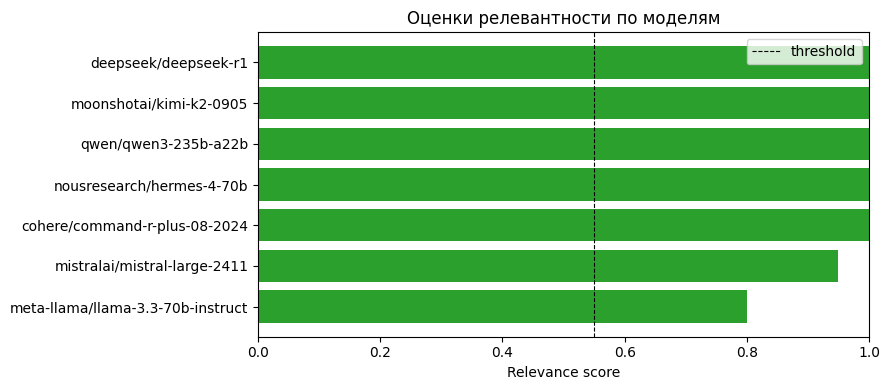

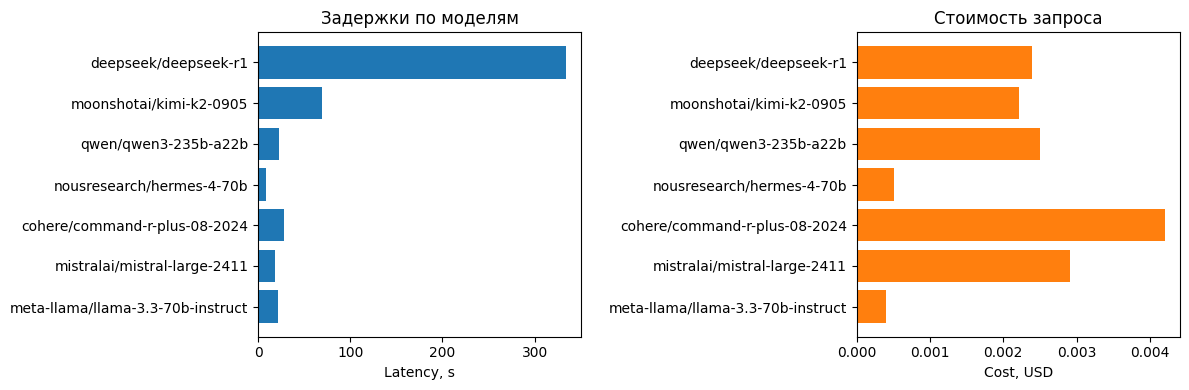

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

def load_trace(path: str | Path) -> List[Dict[str, Any]]:
    return [json.loads(l) for l in Path(path).read_text(encoding="utf-8").splitlines() if l.strip()]

def result_to_frame(result: PipelineResult) -> pd.DataFrame:
    rows = []
    # индекс ответов worker'ов по модели
    by_model = {a.model: a for a in result.raw_answers}
    for e in result.evaluations:
        a = by_model.get(e.model)
        rows.append({
            "model":       e.model,
            "score":       e.score,
            "is_relevant": e.is_relevant,
            "verdict":     e.verdict,
            "latency_s":   getattr(a, "latency_s", None),
            "cost_usd":    getattr(a, "cost_usd", None),
            "cached":      getattr(a, "cached", None),
            "error":       getattr(a, "error", None),
        })
    return pd.DataFrame(rows).sort_values("score", ascending=False)


def plot_scores(df: pd.DataFrame, threshold: float = RELEVANCE_THRESHOLD) -> None:
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ["tab:green" if r else "tab:red" for r in df["is_relevant"]]
    ax.barh(df["model"], df["score"], color=colors)
    ax.axvline(threshold, color="black", linestyle="--", linewidth=0.8, label="threshold")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Relevance score")
    ax.set_title("Оценки релевантности по моделям")
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout(); plt.show()


def plot_cost_latency(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].barh(df["model"], df["latency_s"].fillna(0), color="tab:blue")
    axes[0].set_xlabel("Latency, s"); axes[0].set_title("Задержки по моделям")
    axes[0].invert_yaxis()
    axes[1].barh(df["model"], df["cost_usd"].fillna(0), color="tab:orange")
    axes[1].set_xlabel("Cost, USD"); axes[1].set_title("Стоимость запроса")
    axes[1].invert_yaxis()
    plt.tight_layout(); plt.show()


df = result_to_frame(result)
display(df.head())
plot_scores(df)
plot_cost_latency(df)

## 12. Выводы и направления развития

### 12.1. Выводы по результатам демонстрационного запуска

По итогам демонстрационного запуска можно сделать вывод, что разработанная система в целом работает успешно. На примере запроса о влиянии персональных ИИ-тьюторов на школьное образование в ближайшие 7–10 лет конвейер прошел все основные этапы: сначала был составлен план решения задачи, затем несколько моделей подготовили ответы, после этого ответы были оценены, а в конце был сформирован единый итоговый прогноз.

Планирующий модуль оценил данный запрос как достаточно сложный и подобрал для него 7 моделей. Это можно считать оправданным, поскольку тема действительно требует не только общего рассуждения, но и построения сценариев, выделения факторов влияния, рисков и допущений. Все модели были запущены параллельно, однако общее время выполнения оказалось достаточно большим. Причина заключалась в том, что одна из моделей работала значительно медленнее остальных, и именно из-за нее задержался весь этап генерации ответов. Таким образом, уже на этом примере видно, что даже при параллельном запуске система остается зависимой от самой медленной модели.

Содержательно ответы в целом получились качественными. Большинство моделей соблюдали требуемую структуру, предлагали несколько сценариев развития ситуации, указывали основные факторы и риски. Наиболее сильными можно считать ответы тех моделей, которые не только рассуждали в общем виде, но и давали количественные оценки. Это важно, поскольку задача предполагала именно прогноз с конкретными вариантами развития событий, а не только общее описание возможных последствий.

В то же время ответы различались по степени проработанности. Одни модели давали более детализированное и уверенное обоснование, другие отвечали более общо. Это показывает, что использование нескольких моделей одновременно действительно имеет смысл: итоговый результат получается более устойчивым и более сбалансированным, чем в случае использования только одной модели. Иначе говоря, ансамбль моделей позволяет частично компенсировать недостатки отдельных ответов.

Интересным оказался и вывод по затратам. Анализ показал, что расходы формируются не только на этапе получения ответов от моделей, но и на этапах их оценки и последующего обобщения. Иными словами, заметная часть ресурсов расходуется не только на основную генерацию, но и на вспомогательные процедуры. Это особенно важно учитывать в дальнейшем, если число моделей в системе будет увеличиваться.

Модуль оценки в данном запуске признал все ответы релевантными, то есть соответствующими поставленной задаче. С одной стороны, это можно считать положительным результатом: планирующий модуль подобрал такой набор моделей, который в целом справился с запросом. С другой стороны, это может означать, что порог отбора пока настроен недостаточно строго. Если почти все ответы проходят дальше, системе пока трудно отделять просто приемлемые ответы от действительно сильных.

Итоговый модуль обобщения также показал хорошие результаты. Он не просто собрал ответы вместе, а сформировал цельный прогноз с несколькими сценариями, основными факторами, допущениями и рисками. Благодаря этому итоговый результат получился более связным и удобным для анализа.

Таким образом, демонстрационный запуск подтвердил, что предложенная архитектура может использоваться для решения сложных аналитических задач. Однако одновременно он выявил несколько проблемных мест, связанных со временем выполнения, стоимостью и принципами оценки качества ответов.

### 12.2. Выявленные ограничения

Несмотря на успешный запуск, в работе системы обнаружились ограничения, которые необходимо учитывать.

Во-первых, система сильно зависит от самой медленной модели. Даже если остальные модели уже завершили работу, весь этап генерации не может считаться завершенным, пока не будет получен последний ответ. На практике это может заметно ухудшать удобство использования системы, особенно в тех случаях, когда результат нужен быстро.

Во-вторых, вызывает вопросы объективность оценки ответов. В текущей реализации ответы фактически проверяются той же моделью, которая использовалась для их генерации. Такой подход нельзя считать полностью надёжным, поскольку возникает риск необъективной самооценки. Для более корректной проверки желательно использовать отдельную независимую модель-оценщик.

В-третьих, заметную долю составляют накладные расходы. Существенная часть затрат приходится не только на генерацию ответов, но и на их последующую оценку. Это означает, что при увеличении числа моделей стоимость системы будет расти быстрее, чем может показаться на первый взгляд.

Еще одно ограничение связано с зависимостью от одного внешнего сервиса. Если он окажется недоступен, работа всей системы остановится. С практической точки зрения это снижает надежность решения. Если Open Router перестанет выдавать модели в рамках региона, можно перейти на использование российских вариантов (через API).

Кроме того, модели в данном эксперименте опирались только на свои внутренние знания. Они не использовали свежие источники информации, официальную статистику, новости или внешние базы данных. Поэтому итоговый прогноз можно считать логичным, но не полностью основанным на актуальных данных.

Также важно отметить, что в ноутбуке было выполнено множество демонстрационных запусков, но для презентации результатов был оставлен только один. На основании одного примера нельзя сделать окончательные выводы о стабильности качества работы системы. В будущем для более серьезной оценки необходимо провести серию запусков на разных запросах.

Наконец, всем моделям выдается один и тот же запрос без учета их особенностей. Между тем разные модели лучше справляются с разными типами инструкций. Это значит, что их потенциал в текущей версии используется не полностью.

### 12.3. Направления развития

На основе проведенного анализа можно предложить несколько направлений дальнейшего развития системы.

Прежде всего, стоит ограничить время ожидания ответа от слишком медленных моделей. Если одна из моделей работает существенно дольше остальных, её можно останавливать по заранее заданному пределу времени. Это позволит избежать ситуации, когда весь процесс задерживается из-за одного участника.

Следующее важное направление — сделать оценку ответов более независимой. Лучше, чтобы ответы проверялись не той же моделью, которая их сгенерировала, а отдельной моделью-оценщиком. Это сделает фильтрацию результатов более объективной.

Также полезно добавить предварительную автоматическую проверку ответов до их полноценной оценки. Например, можно заранее проверять, соблюден ли требуемый формат, присутствуют ли обязательные поля и не слишком ли коротким получился ответ. Это позволит отсеивать явно слабые варианты без лишних затрат.

Еще одним улучшением может стать настройка запросов под конкретные модели. В текущей реализации все модели получают одинаковую инструкцию, однако на практике одни модели лучше работают со строгой структурой, другие — с подробными объяснениями, а третьи — с количественными оценками. Если учитывать эти различия, качество итогового результата может повыситься.

Кроме того, перспективным выглядит введение второго раунда взаимодействия между моделями. Например, после первого ответа каждая модель могла бы получить краткое изложение позиций остальных и затем уточнить свой прогноз. Это помогло бы уменьшить разброс мнений и сделать итоговый вывод более согласованным.

Отдельно стоит предусмотреть резервный механизм для итогового обобщения. Если основная модель, отвечающая за финальный вывод, не справится со своей задачей, система должна уметь автоматически переключаться на запасной вариант.

Для более серьезной оценки качества необходимо провести серию повторных запусков на нескольких задачах. Это позволит понять, насколько устойчиво работает система, насколько повторяемы результаты и как сильно они зависят от случайности генерации.

Также представляется важным уточнить сам порог отбора релевантных ответов. Сейчас он, вероятно, слишком мягкий. Необходимы дополнительные эксперименты, чтобы подобрать такое значение, при котором будут сохраняться действительно качественные ответы, а не просто приемлемые.

Наконец, в будущем системе стоит добавить доступ к внешним источникам информации: поиску, открытым базам данных, статистическим материалам и другим актуальным данным. Это позволит строить прогнозы не только на основе внутренних знаний моделей, но и на основе более проверяемой фактической информации.
